In [34]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

#ici on prolonge le test sur le bitcoin et l'etherium , donc invoquons les deux datasets
bitcoin = pd.read_csv("BTC-EUR.csv" , index_col="Date" , parse_dates=True)
etherium = pd.read_csv("ETH-EUR.csv" , index_col="Date" , parse_dates=True)

In [36]:
etherium

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-08-07,0.593000,20.000000,0.593000,2.560000,2.560000,15200
2015-08-08,2.560000,2.598000,0.561600,0.650000,0.650000,32816
2015-08-09,0.650000,0.800000,0.523500,0.700000,0.700000,4041
2015-08-10,0.700000,0.750000,0.585000,0.680000,0.680000,5645
2015-08-11,0.680000,1.008000,0.591500,0.950000,0.950000,21607
...,...,...,...,...,...,...
2019-09-30,155.160004,166.649994,151.229996,165.910004,165.910004,15659055
2019-10-01,165.910004,170.710007,159.330002,161.410004,161.410004,11427525
2019-10-02,161.410004,165.740005,159.699997,165.240005,165.240005,5760811


In [37]:
bitcoin

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2011-10-04,3.700000,3.821000,3.746000,3.750000,3.750000,1357
2011-10-05,3.750000,3.820000,3.650000,3.676000,3.676000,3349
2011-10-06,3.676000,3.743000,3.450000,3.550000,3.550000,6642
2011-10-07,3.550000,3.590000,2.900000,3.293000,3.293000,7135
2011-10-08,3.293000,3.283000,2.872000,2.890000,2.890000,2007
...,...,...,...,...,...,...
2019-09-30,7375.950195,7667.890137,7075.589844,7626.029785,7626.029785,101457908
2019-10-01,7626.029785,7818.279785,7535.799805,7625.560059,7625.560059,75644316
2019-10-02,7625.560059,7663.270020,7489.770020,7655.250000,7655.250000,51871334


In [40]:
#afin d'eviter toute confusion plus tard , renommons la colonne clause de nos deux datasets

etherium= etherium.rename(columns={'Close': 'Close_eth'})
bitcoin = bitcoin.rename(columns={'Close':'Close_btc'})

In [41]:
#assonblons les duex datasets , en mettant l'accent sur une periode d'evolution commune a toutes les deux 
btc_eth=pd.merge(bitcoin, etherium, on="Date", how= "inner" , suffixes= ("_btc","_eth"))
btc_eth


,Open_btc,High_btc,Low_btc,Close_btc,Adj Close_btc,Volume_btc,Open_eth,High_eth,Low_eth,Close_eth,Adj Close_eth,Volume_eth
Date,,,,,,,,,,,,
2015-08-07,255.710007,258.880005,253.639999,256.250000,256.250000,1446808,0.593000,20.000000,0.593000,2.560000,2.560000,15200
2015-08-08,256.250000,257.029999,239.279999,240.199997,240.199997,1426996,2.560000,2.598000,0.561600,0.650000,0.650000,32816
2015-08-09,240.199997,246.110001,239.039993,243.910004,243.910004,797790,0.650000,0.800000,0.523500,0.700000,0.700000,4041
2015-08-10,243.910004,248.039993,240.779999,241.679993,241.679993,1135445,0.700000,0.750000,0.585000,0.680000,0.680000,5645
2015-08-11,241.679993,247.190002,240.399994,245.759995,245.759995,1472221,0.680000,1.008000,0.591500,0.950000,0.950000,21607
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-29,7523.009766,7541.020020,7247.169922,7375.950195,7375.950195,39755968,159.130005,159.779999,150.610001,155.160004,155.160004,7857348
2019-09-30,7375.950195,7667.890137,7075.589844,7626.029785,7626.029785,101457908,155.160004,166.649994,151.229996,165.910004,165.910004,15659055
2019-10-01,7626.029785,7818.279785,7535.799805,7625.560059,7625.560059,75644316,165.910004,170.710007,159.330002,161.410004,161.410004,11427525


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

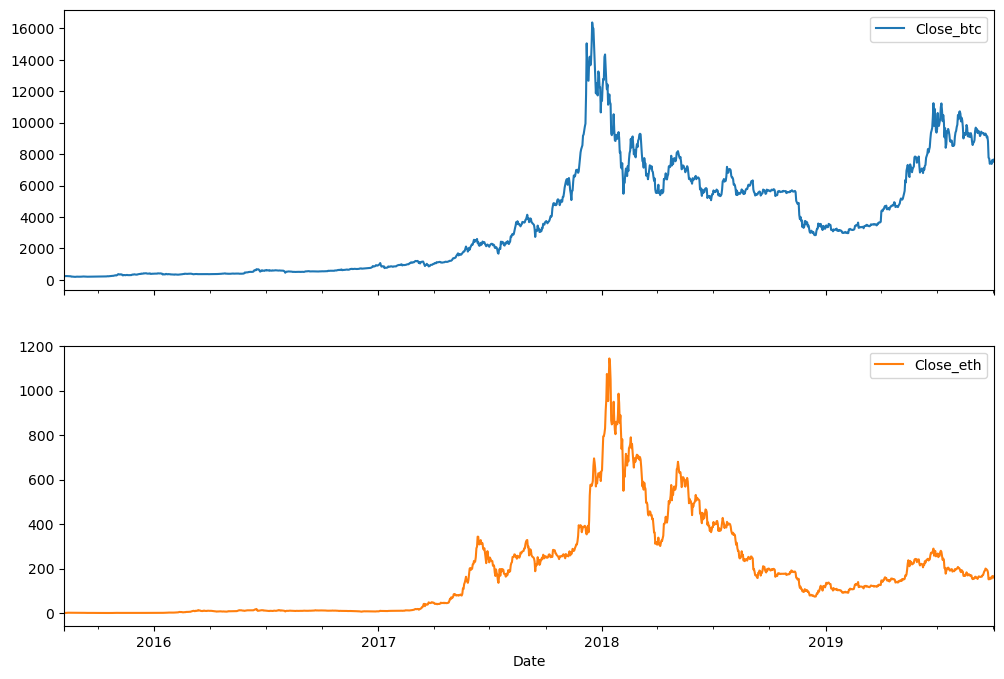

In [43]:
btc_eth[["Close_btc" , 'Close_eth']].plot(subplots=True , figsize=(12,8))

In [46]:
#essayons de calculer la corellation entre les deux cryptomonnaies
correlation=btc_eth[['Close_btc' , 'Close_eth']].corr()
correlation


,Close_btc,Close_eth
Close_btc,1.000000,0.791416
Close_eth,0.791416,1.000000


<Axes: >

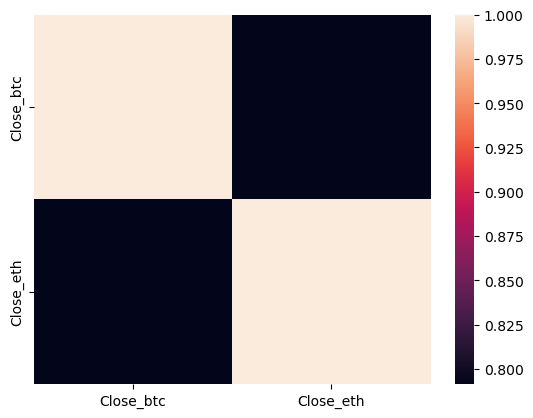

In [48]:
import seaborn as sns
sns.heatmap(correlation)